In [3]:
import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [5]:
dataset.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
dataset['MPG'] = dataset.MPG.astype('float16')
dataset['Cylinders'] = dataset.Cylinders.astype('uint8')
dataset['Displacement'] = dataset.Displacement.astype('float32')
dataset['Horsepower'] = dataset.Horsepower.astype('float16')
dataset['Weight'] = dataset.Weight.astype('float32')
dataset['Acceleration'] = dataset.Acceleration.astype('float16')
dataset['Model Year'] = dataset['Model Year'].astype('uint8')
dataset['Origin'] = dataset.Origin.astype('uint8')

/tmp/ipykernel_50390/3870317942.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset['MPG'] = dataset.MPG.astype('float16')
/tmp/ipykernel_50390/3870317942.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3

In [7]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float16
 1   Cylinders     398 non-null    uint8  
 2   Displacement  398 non-null    float32
 3   Horsepower    392 non-null    float16
 4   Weight        398 non-null    float32
 5   Acceleration  398 non-null    float16
 6   Model Year    398 non-null    uint8  
 7   Origin        398 non-null    uint8  
dtypes: float16(3), float32(2), uint8(3)
memory usage: 6.7 KB


In [9]:
dataset.shape

(398, 8)

In [10]:
dataset = dataset.fillna(dataset.mean(numeric_only=True))

/workspaces/std-carlos-yazid-padilla-royero/.env/lib/python3.14/site-packages/pandas/core/generic.py:7387: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k


In [11]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [12]:
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset.Origin.value_counts()

Origin
1    249
3     79
2     70
Name: count, dtype: int64

In [13]:
# Convierte la columna a categorias.
# Nota. Realmente no se debería hacer asi para aplicaciones
# en productivoddddadadad

dataset["Origin"] = dataset["Origin"].map(
    {   
        1: "USA", 
        2: "Europe", 
        3: "Japan",
    },
).astype('category')

dataset.head(20)

/tmp/ipykernel_50390/3866840349.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset["Origin"] = dataset["Origin"].map(


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA
5,15.0,8,429.0,198.0,4341.0,10.0,70,USA
6,14.0,8,454.0,220.0,4354.0,9.0,70,USA
7,14.0,8,440.0,215.0,4312.0,8.5,70,USA
8,14.0,8,455.0,225.0,4425.0,10.0,70,USA
9,15.0,8,390.0,190.0,3850.0,8.5,70,USA


In [14]:
dataset = pd.get_dummies(dataset, prefix="", prefix_sep="")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


In [15]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

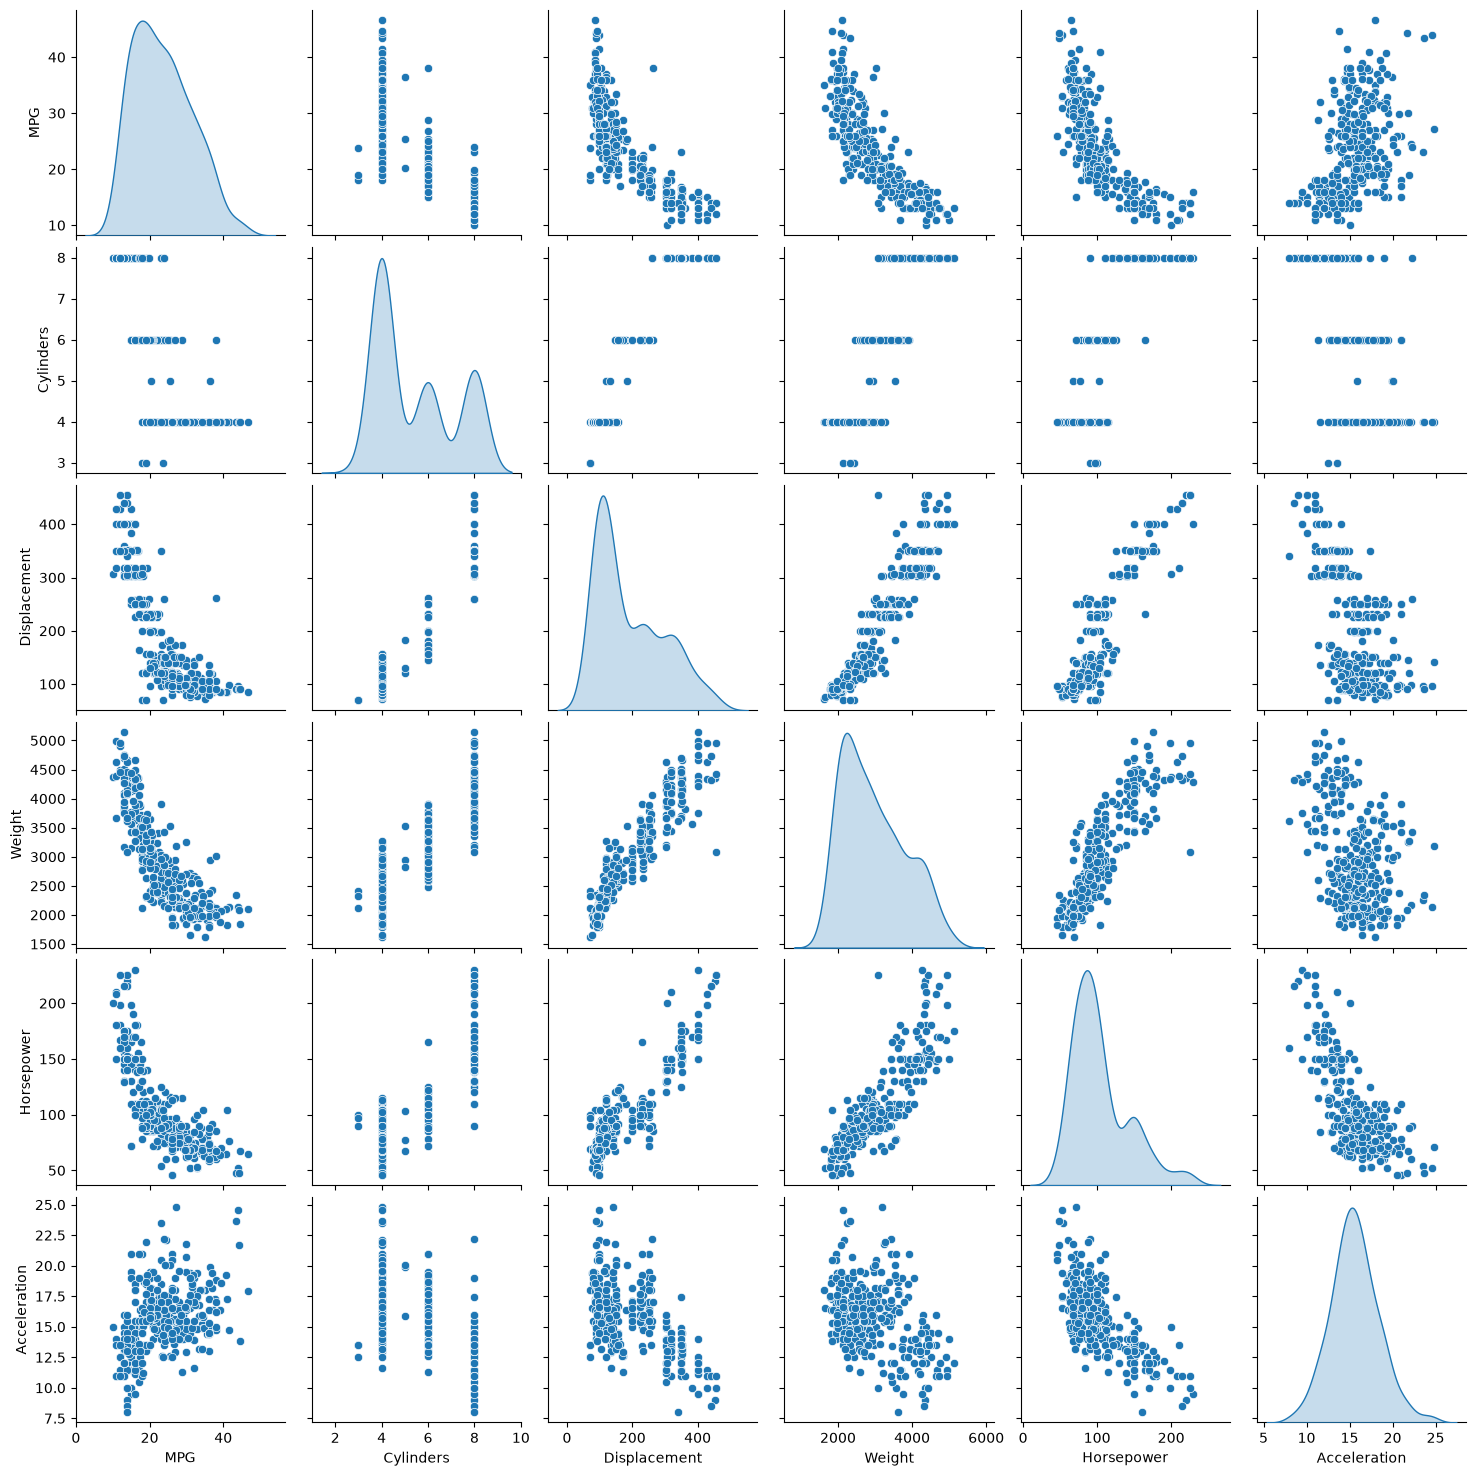

In [16]:
# Las millas por galon (MPG) son función de las demas variables.

import seaborn as sns

g = sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight", "Horsepower", "Acceleration"]],
    diag_kind="kde",
)

In [17]:
dataset.corr(numeric_only=True)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
MPG,1.000000,-0.775390,-0.804203,-0.771429,-0.831733,0.420368,0.579263,0.259072,0.442151,-0.568212
Cylinders,-0.775390,1.000000,0.950721,0.838931,0.896017,-0.505410,-0.348746,-0.352861,-0.396479,0.604351
Displacement,-0.804203,0.950721,1.000000,0.893639,0.932824,-0.543683,-0.370164,-0.373886,-0.433505,0.651407
Horsepower,-0.771429,0.838931,0.893639,1.000000,0.860568,-0.684269,-0.411644,-0.281253,-0.321331,0.486084
Weight,-0.831733,0.896017,0.932824,0.860568,1.000000,-0.417469,-0.306564,-0.298843,-0.440817,0.598398
Acceleration,0.420368,-0.505410,-0.543683,-0.684269,-0.417469,1.000000,0.288146,0.204456,0.109197,-0.250837
Model Year,0.579263,-0.348746,-0.370164,-0.411644,-0.306564,0.288146,1.000000,-0.024489,0.193101,-0.139883
Europe,0.259072,-0.352861,-0.373886,-0.281253,-0.298843,0.204456,-0.024489,1.000000,-0.229895,-0.597198
Japan,0.442151,-0.396479,-0.433505,-0.321331,-0.440817,0.109197,0.193101,-0.229895,1.000000,-0.643317
USA,-0.568212,0.604351,0.651407,0.486084,0.598398,-0.250837,-0.139883,-0.597198,-0.643317,1.000000


In [18]:
# Particionamiento de los datos en features y labels

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standarized_train = scaler.fit_transform(train_features)
standarized_test = scaler.transform(test_features)

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)

reduced_train = pca.fit_transform(standarized_train)
reduced_test = pca.transform(standarized_test)

In [21]:
# Modelo de regresión lineal

#from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#model = LinearRegression()
#model.fit(reduced_train, train_labels)

model = RandomForestRegressor()
model.fit(reduced_train, train_labels)

RandomForestRegressor()

In [22]:
from sklearn.metrics import mean_squared_error

# Se generan predicciones para el conjunto test con la media y stvd calculadas en el conjunto train
y_pred = model.predict(reduced_test)

test_results = mean_squared_error(
    y_true=test_labels,     # y_true:parámetro de la función mean_squared_error que pide los datos de la variable Y y (test_labels [MPG])
    y_pred=y_pred,)         # y_pred: Parámetro de la función mean_squared_error que pide los datos de la variable Y pronosticada (y_pred [MPG])

test_results

5.931603486328126

In [23]:
import pickle

with open(f"../submission/mlp.pkl", "wb") as file:
    pickle.dump(model,file)

with open(f"../submission/features_scaler.pkl", "wb") as file:
    pickle.dump(scaler,file)

with open(f"../submission/reducer.pkl", "wb") as file:
    pickle.dump(pca,file)
